<a href="https://colab.research.google.com/github/ga642381/ML2021-Spring/blob/main/HW02/HW02-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Homework 2-1 Phoneme Classification**

* Slides: https://speech.ee.ntu.edu.tw/~hylee/ml/ml2021-course-data/hw/HW02/HW02.pdf
* Video (Chinese): https://youtu.be/PdjXnQbu2zo
* Video (English): https://youtu.be/ESRr-VCykBs


## The DARPA TIMIT Acoustic-Phonetic Continuous Speech Corpus (TIMIT)
The TIMIT corpus of reading speech has been designed to provide speech data for the acquisition of acoustic-phonetic knowledge and for the development and evaluation of automatic speech recognition systems.

This homework is a multiclass classification task, 
we are going to train a deep neural network classifier to predict the phonemes for each frame from the speech corpus TIMIT.

link: https://academictorrents.com/details/34e2b78745138186976cbc27939b1b34d18bd5b3

## Download Data
Download data from google drive, then unzip it.

You should have `timit_11/train_11.npy`, `timit_11/train_label_11.npy`, and `timit_11/test_11.npy` after running this block.<br><br>
`timit_11/`
- `train_11.npy`: training data<br>
- `train_label_11.npy`: training label<br>
- `test_11.npy`:  testing data<br><br>

**notes: if the google drive link is dead, you can download the data directly from Kaggle and upload it to the workspace**




In [1]:
import gdown
import os

# 判斷目標資料夾是否已經存在
if not os.path.exists('./timit_11'):
    print("🔽 找不到資料集，開始下載...")
    url = 'https://drive.google.com/uc?id=1HPkcmQmFGu-30knddKIa5dNDsRO5lIQR'
    
    # 也可以順便檢查壓縮檔是不是已經載過了，避免重複下載
    if not os.path.exists('data.zip'):
        gdown.download(url, 'data.zip', quiet=False)
    
    print("📦 開始解壓縮...")
    # 加上 -o 參數 (overwrite) 告訴系統：如果檔案存在就直接無腦覆蓋，不要停下來問我
    os.system('unzip -o data.zip')
    
    print("✅ 資料處理完畢！")
else:
    print("🎉 資料集已經存在，直接跳過下載與解壓縮，節省你的時間！")

🎉 資料集已經存在，直接跳過下載與解壓縮，節省你的時間！


## Preparing Data
Load the training and testing data from the `.npy` file (NumPy array).

In [2]:
import numpy as np

print('Loading data ...')

# 直接給它最精確的絕對路徑，不讓它亂跑
data_root = '/home/sean8/projects/ML_Lee/ML2021-Spring/HW02/timit_11/'

train = np.load(data_root + 'train_11.npy')
train_label =    np.load(data_root + 'train_label_11.npy')
test = np.load(data_root + 'test_11.npy')

print('Size of training data: {}'.format(train.shape))
print('Size of testing data: {}'.format(test.shape))

Loading data ...
Size of training data: (1229932, 429)
Size of testing data: (451552, 429)


## Create Dataset

In [3]:
import torch
from torch.utils.data import Dataset

class TIMITDataset(Dataset):
    def __init__(self, X, y=None):
        self.data = torch.from_numpy(X).float()
        if y is not None:
            y = y.astype(int)
            self.label = torch.LongTensor(y)
        else:
            self.label = None

    def __getitem__(self, idx):
        if self.label is not None:
            return self.data[idx], self.label[idx]
        else:
            return self.data[idx]

    def __len__(self):
        return len(self.data)


Split the labeled data into a training set and a validation set, you can modify the variable `VAL_RATIO` to change the ratio of validation data.

In [4]:
VAL_RATIO = 0.2 # 20% 的資料拿來驗證

percent = int(train.shape[0] * (1 - VAL_RATIO))
train_x, train_y, val_x, val_y = train[:percent], train_label[:percent], train[percent:], train_label[percent:]
print('Size of training set: {}'.format(train_x.shape))
print('Size of validation set: {}'.format(val_x.shape))

import numpy as np

mean = np.mean(train_x, axis=0)
std = np.std(train_x, axis=0)

# 避免除以零，加上 1e-8
train_x = (train_x - mean) / (std + 1e-8)
val_x = (val_x - mean) / (std + 1e-8) # FEATURE NORMALIZATION

Size of training set: (983945, 429)
Size of validation set: (245987, 429)


Create a data loader from the dataset, feel free to tweak the variable `BATCH_SIZE` here.

In [5]:
BATCH_SIZE = 256

from torch.utils.data import DataLoader

train_set = TIMITDataset(train_x, train_y)
val_set = TIMITDataset(val_x, val_y)
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True) #only shuffle the training data
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)

Cleanup the unneeded variables to save memory.<br>

**notes: if you need to use these variables later, then you may remove this block or clean up unneeded variables later<br>the data size is quite huge, so be aware of memory usage in colab**

In [6]:
import gc

del train, train_label, train_x, train_y, val_x, val_y
gc.collect()

20

## Create Model

Define model architecture, you are encouraged to change and experiment with the model architecture.

In [7]:
import torch.nn as nn

class Classifier(nn.Module):
    def __init__(self):
        super(Classifier, self).__init__()
        
        # 設定 Dropout 的機率 (通常設 0.2 到 0.5 之間，先用 0.25 試水溫)
        drop_rate = 0.35
        
        # 使用 nn.Sequential 打包每一層的 Block
        self.layer1 = nn.Sequential(
            nn.Linear(429, 2048),
            nn.BatchNorm1d(2048),    # BN 的維度必須和 Linear 的輸出維度一樣
            nn.ReLU(),               # 換成 ReLU
            nn.Dropout(drop_rate)
        )
        
        self.layer2 = nn.Sequential(
            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(drop_rate)
        )
        
        self.layer3 = nn.Sequential(
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(drop_rate)
        )
        
        self.layer4 = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(drop_rate)
        )
        
        self.layer5 = nn.Sequential(
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(drop_rate)
        )
        
        self.out = nn.Linear(64, 39)

    def forward(self, x):
        # 這樣 forward 就會變得超級乾淨
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = self.out(x)
        return x

In [8]:
import matplotlib.pyplot as plt

def plot_learning_curve(history, save_path='my_hw02_curve.png'):
    """
    讀取訓練紀錄 (history) 並畫出 Loss 與 Accuracy 的學習曲線
    """
    epochs = range(1, len(history['train_loss']) + 1)
    
    # 設定畫布大小 (寬 12, 高 5)
    plt.figure(figsize=(12, 5))
    
    # --- 第一張圖：Loss 曲線 ---
    plt.subplot(1, 2, 1) # 1 row, 2 columns, 第 1 張圖
    plt.plot(epochs, history['train_loss'], label='Train Loss', color='tab:blue')
    plt.plot(epochs, history['val_loss'], label='Val Loss', color='tab:orange', linestyle='--')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # --- 第二張圖：Accuracy 曲線 ---
    plt.subplot(1, 2, 2) # 1 row, 2 columns, 第 2 張圖
    plt.plot(epochs, history['train_acc'], label='Train Acc', color='tab:blue')
    plt.plot(epochs, history['val_acc'], label='Val Acc', color='tab:orange', linestyle='--')
    
    # 畫一條參考線 (以 Strong Baseline 預估為 0.75 為例)
    plt.axhline(y=0.75, color='red', linestyle=':', label='Strong Baseline (0.75)')
    
    plt.title('Training & Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # 自動排版避免文字重疊，並存成圖片檔
    plt.tight_layout()
    plt.savefig(save_path, dpi=300) # 存下高畫質圖片
    print(f"📊 學習曲線圖已儲存為: {save_path}")
    
    # 如果你在 Jupyter/Colab 上，這行會直接把圖顯示出來
    plt.show()

## Training

In [9]:
#check device
def get_device():
  return 'cuda' if torch.cuda.is_available() else 'cpu'

Fix random seeds for reproducibility.

In [10]:
# fix random seed
def same_seeds(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  
    np.random.seed(seed)  
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

Feel free to change the training parameters here.

In [ ]:
# fix random seed for reproducibility
same_seeds(0)

# get device 
device = get_device()
print(f'DEVICE: {device}')

# training parameters
num_epoch = 40               # number of training epoch
learning_rate = 0.0001       # learning rate

# the path where checkpoint saved
model_path = './model.ckpt'

# create model, define a loss function, and optimizer
model = Classifier().to(device)
criterion = nn.CrossEntropyLoss() 
# 🌟 換上新引擎，並設定萬用的權重衰減初始值 1e-4
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
# 讓學習率隨著 Epoch 像溜滑梯一樣慢慢變小
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epoch)

DEVICE: cuda


[001/040] Train Acc: 0.558346 Loss: 1.518781 | Val Acc: 0.671849 loss: 1.059021
saving model with acc 0.672
[002/040] Train Acc: 0.630711 Loss: 1.244721 | Val Acc: 0.699167 loss: 0.954689
saving model with acc 0.699
[003/040] Train Acc: 0.656126 Loss: 1.150426 | Val Acc: 0.711460 loss: 0.907910
saving model with acc 0.711
[004/040] Train Acc: 0.673114 Loss: 1.089292 | Val Acc: 0.720721 loss: 0.879256
saving model with acc 0.721
[005/040] Train Acc: 0.685295 Loss: 1.044922 | Val Acc: 0.726022 loss: 0.855276
saving model with acc 0.726
[006/040] Train Acc: 0.695037 Loss: 1.007881 | Val Acc: 0.731250 loss: 0.838655
saving model with acc 0.731
[007/040] Train Acc: 0.701951 Loss: 0.981585 | Val Acc: 0.734336 loss: 0.829415
saving model with acc 0.734
[008/040] Train Acc: 0.709523 Loss: 0.954541 | Val Acc: 0.736348 loss: 0.822077
saving model with acc 0.736
[009/040] Train Acc: 0.715017 Loss: 0.933944 | Val Acc: 0.740035 loss: 0.811478
saving model with acc 0.740
[010/040] Train Acc: 0.72011

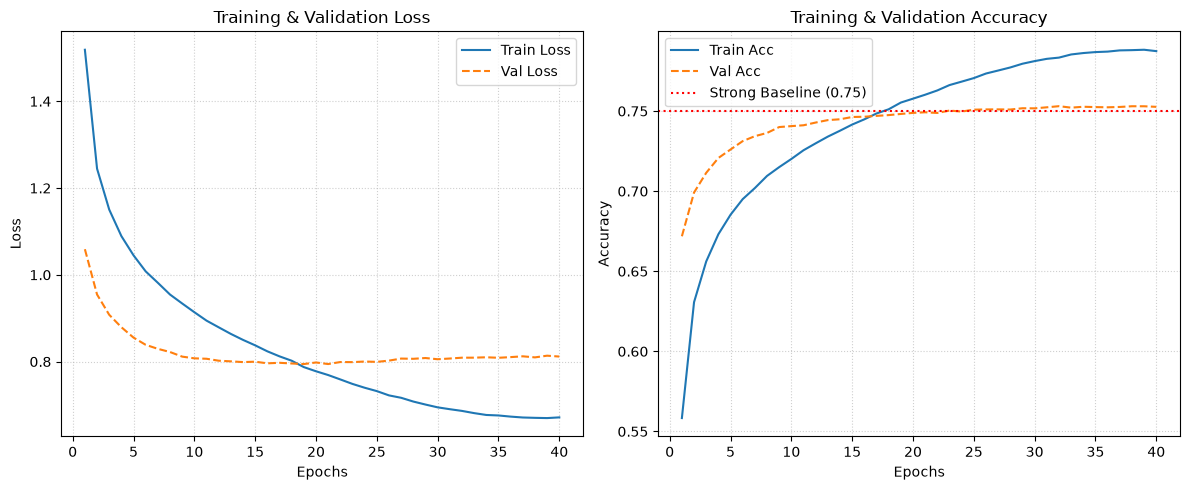

In [12]:
# start training
history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}
best_acc = 0.0

for epoch in range(num_epoch):
    train_acc = 0.0
    train_loss = 0.0
    val_acc = 0.0
    val_loss = 0.0

    # ================= training =================
    model.train() # set the model to training mode
    for i, data in enumerate(train_loader):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad() 
        outputs = model(inputs) 
        batch_loss = criterion(outputs, labels)
        _, train_pred = torch.max(outputs, 1) # get the index of the class with the highest probability
        batch_loss.backward() 
        optimizer.step() 

        train_acc += (train_pred.cpu() == labels.cpu()).sum().item()
        train_loss += batch_loss.item()

    # ================= validation =================
    if len(val_set) > 0:
        model.eval() # set the model to evaluation mode
        with torch.no_grad():
            for i, data in enumerate(val_loader):
                inputs, labels = data
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                batch_loss = criterion(outputs, labels) 
                _, val_pred = torch.max(outputs, 1) 
            
                val_acc += (val_pred.cpu() == labels.cpu()).sum().item() 
                val_loss += batch_loss.item()
                
    # 🌟 關鍵修復：先在這裡把這回合的平均分數算好，並存進變數裡
    epoch_train_acc = train_acc / len(train_set)
    epoch_train_loss = train_loss / len(train_loader)
    
    if len(val_set) > 0:
        epoch_val_acc = val_acc / len(val_set)
        epoch_val_loss = val_loss / len(val_loader)
    else:
        epoch_val_acc = 0.0
        epoch_val_loss = 0.0

    # 印出這回合的成績 (直接使用剛剛算好的變數)
    if len(val_set) > 0:
        print('[{:03d}/{:03d}] Train Acc: {:3.6f} Loss: {:3.6f} | Val Acc: {:3.6f} loss: {:3.6f}'.format(
            epoch + 1, num_epoch, epoch_train_acc, epoch_train_loss, epoch_val_acc, epoch_val_loss
        ))

        # if the model improves, save a checkpoint at this epoch
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), model_path)
            print('saving model with acc {:.3f}'.format(best_acc/len(val_set)))
    else:
        print('[{:03d}/{:03d}] Train Acc: {:3.6f} Loss: {:3.6f}'.format(
            epoch + 1, num_epoch, epoch_train_acc, epoch_train_loss
        ))

    # 🌟 安全存入：可以順利抄寫進 history 紀錄本裡！
    history['train_acc'].append(epoch_train_acc)
    history['train_loss'].append(epoch_train_loss)
    history['val_acc'].append(epoch_val_acc)
    history['val_loss'].append(epoch_val_loss)
    
    # 更新學習率步伐
    scheduler.step()

# ================= 訓練結束後的收尾 =================
# if not validating, save the last epoch
if len(val_set) == 0:
    torch.save(model.state_dict(), model_path)
    print('saving model at last epoch')

# 🌟 畫圖大功告成：退回最左邊，迴圈跑完才會執行這行
print("\n訓練結束，正在為您繪製學習曲線圖...")
plot_learning_curve(history, save_path='my_hw02_curve.png')

## Testing

Create a testing dataset, and load model from the saved checkpoint.

In [13]:
# create testing dataset
test_set = TIMITDataset(test, None)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

# create model and load weights from checkpoint
model = Classifier().to(device)
model.load_state_dict(torch.load(model_path))

<All keys matched successfully>

Make prediction.

In [14]:
predict = []
model.eval() # set the model to evaluation mode
with torch.no_grad():
    for i, data in enumerate(test_loader):
        inputs = data
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, test_pred = torch.max(outputs, 1) # get the index of the class with the highest probability

        for y in test_pred.cpu().numpy():
            predict.append(y)

Write prediction to a CSV file.

After finish running this block, download the file `prediction.csv` from the files section on the left-hand side and submit it to Kaggle.

In [15]:
with open('prediction.csv', 'w') as f:
    f.write('Id,Class\n')
    for i, y in enumerate(predict):
        f.write('{},{}\n'.format(i, y))